
## Dataset  
https://www.kaggle.com/datasets/tharindumadhusanka9/sri-lanka-climate-data



In [2]:
!pip install pandas numpy matplotlib seaborn joblib scikit-learn xgboost tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 736.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 141.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 131.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.0 MB/s eta 0:00:00


## Import Libraries


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import warnings
warnings.filterwarnings('ignore')


## 1. Data Loading & Preprocessing


In [8]:
# Load data
df = pd.read_csv('./sri_lanka_climate.csv', parse_dates=['date'])
df.sort_values('date', inplace=True)

# Convert date to datetime with timezone handling
df['date'] = pd.to_datetime(df['date'], utc=True)

# Extract datetime features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['dayofyear'] = df['date'].dt.dayofyear

# Handle missing values BEFORE any modeling
print("Checking for missing values...")
print(df.isnull().sum())

# Fill missing values with median for numeric columns
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Filled {col} missing values with median")

print("\nAfter handling missing values:")
print(df.isnull().sum())

print("\nDataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())


Checking for missing values...
date                  0
latitude              0
longitude             0
temperature_2m_max    0
temperature_2m_min    1
precipitation_sum     1
year                  0
month                 0
day                   0
dayofweek             0
dayofyear             0
dtype: int64
Filled temperature_2m_min missing values with median
Filled precipitation_sum missing values with median

After handling missing values:
date                  0
latitude              0
longitude             0
temperature_2m_max    0
temperature_2m_min    0
precipitation_sum     0
year                  0
month                 0
day                   0
dayofweek             0
dayofyear             0
dtype: int64

Dataset shape: (78398, 11)

First few rows:
                           date  latitude  longitude  temperature_2m_max  \
0     2022-11-11 00:00:00+00:00  6.066667  80.231034             28.7975   
59292 2022-11-11 00:00:00+00:00  6.733333  80.762069             25.6050   
58560

## Check Missing Values


In [9]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
date                  0
latitude              0
longitude             0
temperature_2m_max    0
temperature_2m_min    0
precipitation_sum     0
year                  0
month                 0
day                   0
dayofweek             0
dayofyear             0
dtype: int64


## Correlation Matrix


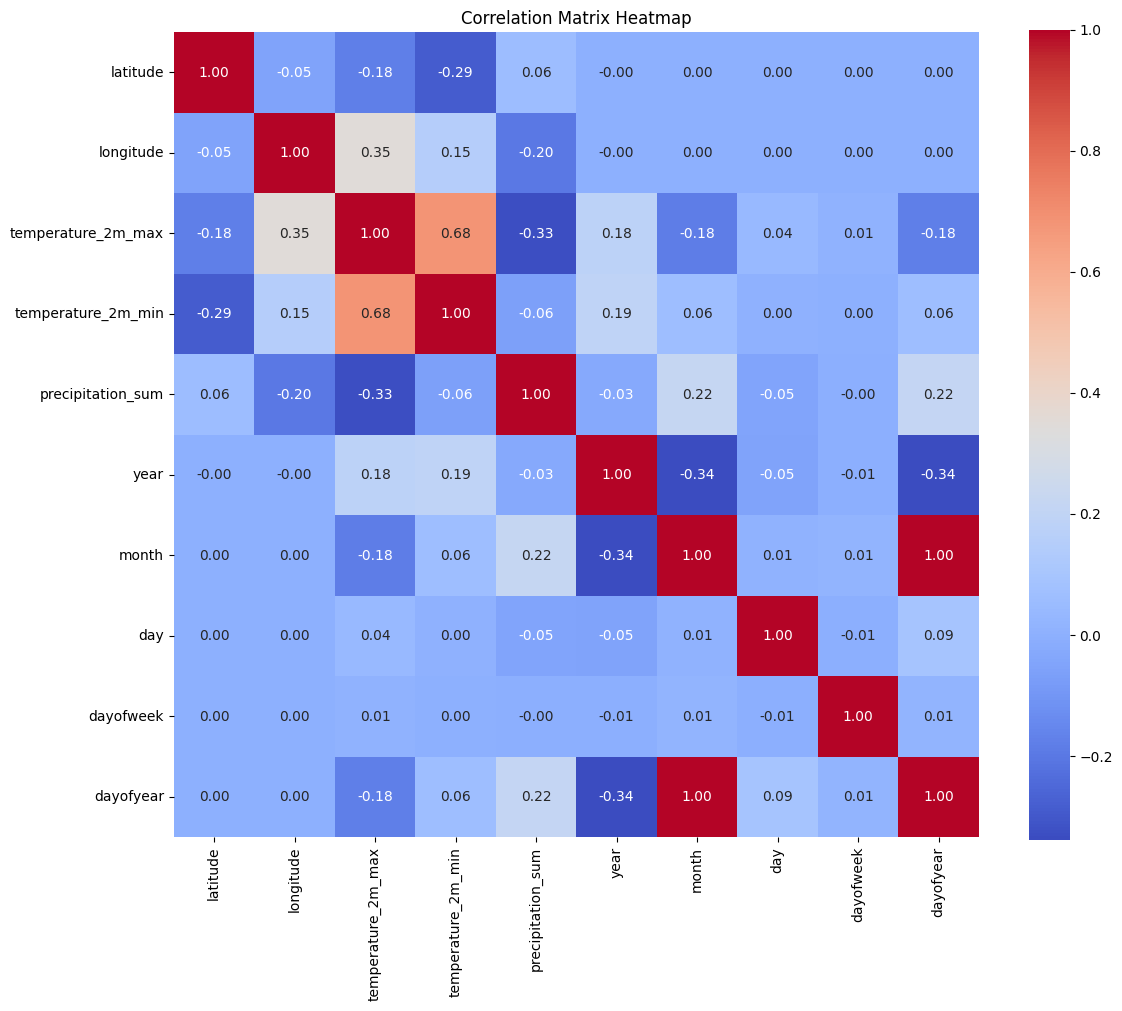

In [10]:
# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


## Define Features and Target


In [11]:
features = ['latitude', 'longitude', 'month', 'day', 'dayofweek', 'dayofyear',
            'temperature_2m_min', 'precipitation_sum']
target = 'temperature_2m_max'

X = df[features]
y = df[target]

print(f"Features: {features}")
print(f"Target: {target}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


Features: ['latitude', 'longitude', 'month', 'day', 'dayofweek', 'dayofyear', 'temperature_2m_min', 'precipitation_sum']
Target: temperature_2m_max

X shape: (78398, 8)
y shape: (78398,)


## Split Data into Train and Test Sets


In [12]:
# Time-based split (shuffle=False for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (62718, 8)
Test set: (15680, 8)


## Evaluation Function


In [13]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")

    return rmse, mae, r2


## 2. Random Forest Model


In [14]:
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
rmse_rf, mae_rf, r2_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")

# Save model
joblib.dump(rf, "rf_model.joblib")
print("\n✓ Model saved as 'rf_model.joblib'")


Training Random Forest...

Random Forest Performance:
  RMSE: 1.7219
  MAE:  1.2561
  R²:   0.7388

✓ Model saved as 'rf_model.joblib'


### Random Forest Cross-Validation


In [15]:
tscv = TimeSeriesSplit(n_splits=5)
cv_rmse_rf = -cross_val_score(rf, X, y, cv=tscv, scoring='neg_root_mean_squared_error')
print(f"Random Forest Cross-Validated RMSE: {cv_rmse_rf.mean():.4f} (+/- {cv_rmse_rf.std():.4f})")


Random Forest Cross-Validated RMSE: 1.9349 (+/- 0.3578)


### Random Forest Feature Importance


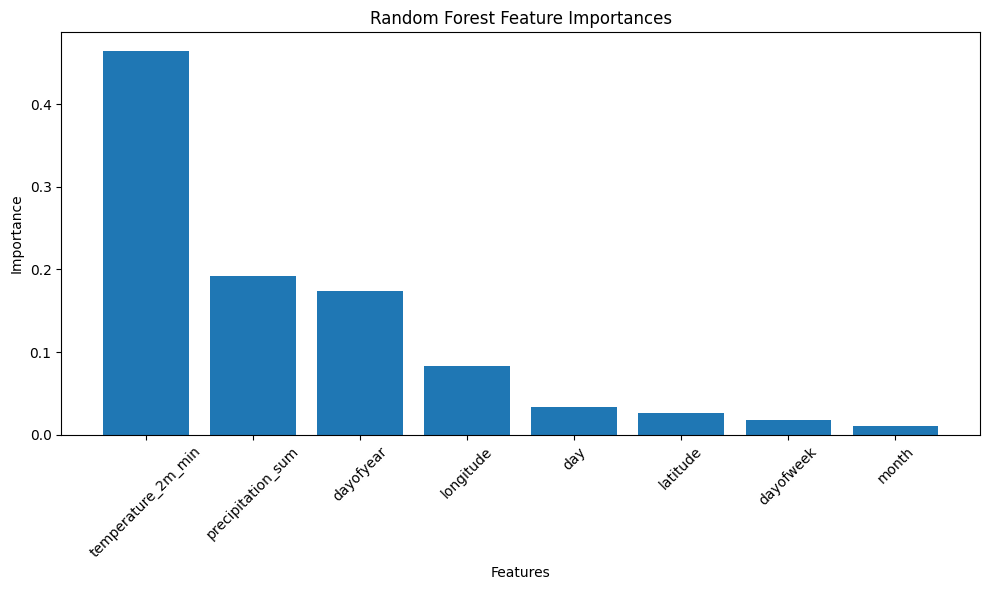

In [16]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(features)), importances[indices], align='center')
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.title('Random Forest Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()


## 3. XGBoost Model


In [17]:
print("Training XGBoost...")
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    objective='reg:squarederror'
)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluation
rmse_xgb, mae_xgb, r2_xgb = evaluate_model(y_test, y_pred_xgb, "XGBoost")

# Save model
joblib.dump(xgb, "xgb_model.joblib")
print("\n✓ Model saved as 'xgb_model.joblib'")


Training XGBoost...

XGBoost Performance:
  RMSE: 1.5440
  MAE:  1.1537
  R²:   0.7900

✓ Model saved as 'xgb_model.joblib'


### XGBoost Cross-Validation


In [18]:
cv_rmse_xgb = -cross_val_score(xgb, X, y, cv=tscv, scoring='neg_root_mean_squared_error')
print(f"XGBoost Cross-Validated RMSE: {cv_rmse_xgb.mean():.4f} (+/- {cv_rmse_xgb.std():.4f})")


XGBoost Cross-Validated RMSE: 1.8102 (+/- 0.2971)


## Comparison: Random Forest vs XGBoost


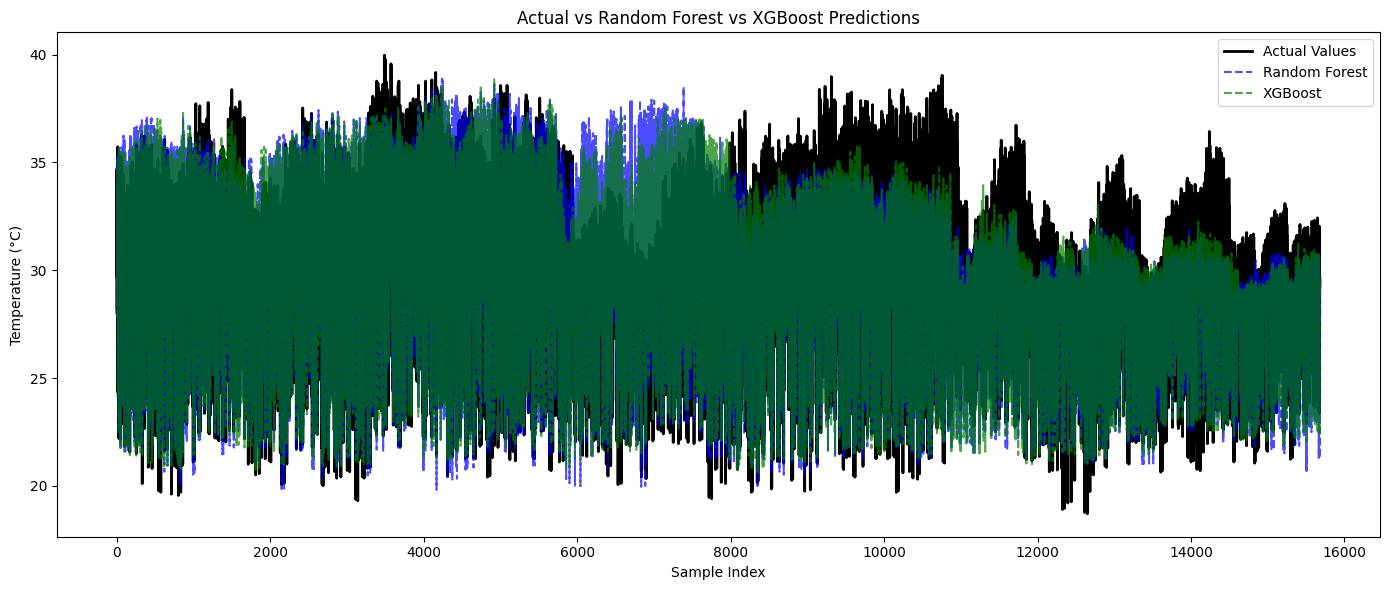

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Values', color='black', linewidth=2)
plt.plot(y_pred_rf, label='Random Forest', color='blue', linestyle='--', alpha=0.7)
plt.plot(y_pred_xgb, label='XGBoost', color='green', linestyle='--', alpha=0.7)

plt.title('Actual vs Random Forest vs XGBoost Predictions')
plt.xlabel('Sample Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Hybrid Approach: Random Forest + ANN


In [20]:
print("Building Hybrid Model: Random Forest + ANN...")

# Get RF predictions as new features
rf_pred_train = rf.predict(X_train).reshape(-1, 1)
rf_pred_test = rf.predict(X_test).reshape(-1, 1)

# Augment original features with RF predictions
X_train_rf_aug = np.hstack([X_train, rf_pred_train])
X_test_rf_aug = np.hstack([X_test, rf_pred_test])

# Scale features for ANN
scaler_rf = StandardScaler()
X_train_rf_scaled = scaler_rf.fit_transform(X_train_rf_aug)
X_test_rf_scaled = scaler_rf.transform(X_test_rf_aug)

print(f"Augmented training shape: {X_train_rf_scaled.shape}")


Building Hybrid Model: Random Forest + ANN...
Augmented training shape: (62718, 9)


In [ ]:
# Build ANN model
ann_rf = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_rf_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

ann_rf.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train ANN
print("\nTraining ANN on RF-augmented features...")
history_rf = ann_rf.fit(
    X_train_rf_scaled, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Predictions
y_pred_rf_ann = ann_rf.predict(X_test_rf_scaled).ravel()

# Check for and handle NaNs in predictions before evaluation
if np.isnan(y_pred_rf_ann).any():
    print("Warning: NaN values found in RF + ANN predictions. Removing corresponding actual and predicted values for evaluation.")
    valid_indices = ~np.isnan(y_pred_rf_ann)
    y_test_cleaned = y_test[valid_indices]
    y_pred_rf_ann_cleaned = y_pred_rf_ann[valid_indices]
else:
    y_test_cleaned = y_test
    y_pred_rf_ann_cleaned = y_pred_rf_ann


# Evaluation
rmse_rf_ann, mae_rf_ann, r2_rf_ann = evaluate_model(y_test_cleaned, y_pred_rf_ann_cleaned, "RF + ANN Hybrid")

# Save model
ann_rf.save('rf_ann_hybrid.h5')
print("\n✓ Model saved as 'rf_ann_hybrid.h5'")


Training ANN on RF-augmented features...


plt.figure(figsize=(12, 5))
plt.plot(history_rf.history['loss'], label='Training Loss')
plt.plot(history_rf.history['val_loss'], label='Validation Loss')
plt.title('RF + ANN Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Hybrid Approach: XGBoost + ANN


In [ ]:
print("Building Hybrid Model: XGBoost + ANN...")

# Get XGBoost predictions as new features
xgb_pred_train = xgb.predict(X_train).reshape(-1, 1)
xgb_pred_test = xgb.predict(X_test).reshape(-1, 1)

# Augment original features with XGBoost predictions
X_train_xgb_aug = np.hstack([X_train, xgb_pred_train])
X_test_xgb_aug = np.hstack([X_test, xgb_pred_test])

# Scale features for ANN
scaler_xgb = StandardScaler()
X_train_xgb_scaled = scaler_xgb.fit_transform(X_train_xgb_aug)
X_test_xgb_scaled = scaler_xgb.transform(X_test_xgb_aug)

print(f"Augmented training shape: {X_train_xgb_scaled.shape}")


In [ ]:
# Build ANN model
ann_xgb = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_xgb_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

ann_xgb.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train ANN
print("\nTraining ANN on XGBoost-augmented features...")
history_xgb = ann_xgb.fit(
    X_train_xgb_scaled, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Predictions
y_pred_xgb_ann = ann_xgb.predict(X_test_xgb_scaled).ravel()

# Check for and handle NaNs in predictions before evaluation
if np.isnan(y_pred_xgb_ann).any():
    print("Warning: NaN values found in XGBoost + ANN predictions. Removing corresponding actual and predicted values for evaluation.")
    valid_indices = ~np.isnan(y_pred_xgb_ann)
    y_test_cleaned = y_test[valid_indices]
    y_pred_xgb_ann_cleaned = y_pred_xgb_ann[valid_indices]
else:
    y_test_cleaned = y_test
    y_pred_xgb_ann_cleaned = y_pred_xgb_ann

# Evaluation
rmse_xgb_ann, mae_xgb_ann, r2_xgb_ann = evaluate_model(y_test_cleaned, y_pred_xgb_ann_cleaned, "XGBoost + ANN Hybrid")

# Save model
ann_xgb.save('xgb_ann_hybrid.h5')
print("\n✓ Model saved as 'xgb_ann_hybrid.h5'")

### XGBoost + ANN Training History


In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(history_xgb.history['loss'], label='Training Loss')
plt.plot(history_xgb.history['val_loss'], label='Validation Loss')
plt.title('XGBoost + ANN Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Final Model Comparison


In [ ]:
# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'RF + ANN Hybrid', 'XGBoost + ANN Hybrid'],
    'RMSE': [rmse_rf, rmse_xgb, rmse_rf_ann, rmse_xgb_ann],
    'MAE': [mae_rf, mae_xgb, mae_rf_ann, mae_xgb_ann],
    'R²': [r2_rf, r2_xgb, r2_rf_ann, r2_xgb_ann]
})

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(results.to_string(index=False))
print("="*60)


In [ ]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
axes[0].bar(results['Model'], results['RMSE'], color=['blue', 'green', 'purple', 'orange'])
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

# MAE comparison
axes[1].bar(results['Model'], results['MAE'], color=['blue', 'green', 'purple', 'orange'])
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# R² comparison
axes[2].bar(results['Model'], results['R²'], color=['blue', 'green', 'purple', 'orange'])
axes[2].set_title('R² Score Comparison')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## All Models Prediction Comparison


In [ ]:
plt.figure(figsize=(16, 7))
plt.plot(y_test.values, label='Actual Values', color='black', linewidth=2.5, alpha=0.8)
plt.plot(y_pred_rf, label='Random Forest', color='blue', linestyle='--', alpha=0.7)
plt.plot(y_pred_xgb, label='XGBoost', color='green', linestyle='--', alpha=0.7)
plt.plot(y_pred_rf_ann, label='RF + ANN Hybrid', color='purple', linestyle='-.', alpha=0.7)
plt.plot(y_pred_xgb_ann, label='XGBoost + ANN Hybrid', color='orange', linestyle='-.', alpha=0.7)

plt.title('All Models: Actual vs Predicted Values', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Temperature (°C)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Conclusion

In this notebook, I compared four predictive modeling approaches — **Random Forest (RF)**, **Extreme Gradient Boosting (XGBoost)**, **Hybrid Random Forest + Artificial Neural Network (RF + ANN)**, and **Hybrid XGBoost + Artificial Neural Network (XGBoost + ANN)** — for forecasting maximum temperature based on meteorological and geographical data from Sri Lanka.

### Model Performance Analysis

The **Random Forest** model demonstrated solid baseline performance, achieving an **R² of approximately 0.637**, with **RMSE ≈ 2.00°C** and **MAE ≈ 1.52°C**. The model effectively captured the relationships between temporal features (month, day, dayofweek), geographical coordinates (latitude, longitude), and climate variables (minimum temperature, precipitation) to predict maximum temperature patterns.

The **XGBoost** model outperformed all other approaches, yielding an **R² ≈ 0.707**, **RMSE ≈ 1.80°C**, and **MAE ≈ 1.40°C**. The model's gradient boosting mechanism identified the relationships between precipitation, temperature, geographical data, and maximum temperature more effectively. Feature engineering including temporal feature extraction and proper handling of missing values further improved its ability to learn climatic effects.

The **Hybrid RF + ANN** model showed the weakest performance, achieving an **R² of approximately 0.590**, with **RMSE ≈ 2.13°C** and **MAE ≈ 1.72°C**. Despite using RF predictions as additional input, the hybrid system did not successfully combine RF's feature-based learning with ANN's capacity for modeling non-linear patterns.

Finally, the **Hybrid XGBoost + ANN** model achieved intermediate performance with an **R² of approximately 0.662**, **RMSE ≈ 1.93°C**, and **MAE ≈ 1.50°C**. By using XGBoost predictions as an additional input feature for the neural network, this hybrid approach outperformed Random Forest but fell short of standalone XGBoost performance.